# Table of Contents

1. [Data Preparation](#data-preparation)
2. [Exploratory Data Analysis](#exploratory-data-analysis)
3. [Modeling](#modeling)
   - [Logistic Regression](#logistic-regression)
   - [Random Forest](#random-forest)
   - [Gradient Boosting](#gradient-boosting)
4. [Model Evaluation](#model-evaluation)
5. [Model Interpretation](#model-interpretation)
6. [Association Analysis](#association-analysis)
7. [Conclusion](#conclusion)

#### Imports

In [ ]:
# Data manipulation
import pandas as pd
import matplotlib.pyplot as plt

### Initial Data Preparation

The `id` column is removed because it serves only as a unique record identifier and contains no predictive information.

The `Driving_License` variable is also removed because over 99% of customers possess a valid driver's license, resulting in extremely low variability. Features with little variation contribute minimal predictive information and are therefore excluded from the analysis.

In [2]:
raw_data = pd.read_csv("../01_data/raw_full.csv")

df = raw_data.copy()

df = df.drop(columns=["id", "Driving_License"])

# Modeling

## Train / Test Split

The dataset is partitioned into training and test sets using an 80/20 stratified split to preserve the original response rate. All preprocessing, model selection, and hyperparameter tuning are performed using the training set only. The held-out test set is reserved for final model evaluation to provide an unbiased assessment of model performance.

In [7]:
from sklearn.model_selection import train_test_split

# Create a copy for modeling
df_model = df.copy()

# Perform an 80/20 stratified train-test split
train_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    stratify=df_model["Response"],
    random_state=42
)

print("Train/Test split dimensions:")
print(f"Training set: {train_df.shape}")
print(f"Testing set:  {test_df.shape}")

print("\nResponse class counts:")
response_dist = pd.DataFrame({
    "Original": df_model["Response"].value_counts(),
    "Train": train_df["Response"].value_counts(),
    "Test": test_df["Response"].value_counts()
})

display(response_dist)

print("Response class proportions:")
response_dist_prop = pd.DataFrame({
    "Original": df_model["Response"].value_counts(normalize=True),
    "Train": train_df["Response"].value_counts(normalize=True),
    "Test": test_df["Response"].value_counts(normalize=True)
}).round(4)

display(response_dist_prop)

Train/Test split dimensions:
Training set: (304887, 10)
Testing set:  (76222, 10)

Response class counts:


,Original,Train,Test
Response,,,
0,334399,267519,66880
1,46710,37368,9342


Response class proportions:


,Original,Train,Test
Response,,,
0,0.8774,0.8774,0.8774
1,0.1226,0.1226,0.1226


In [9]:
# Separate predictors and target variable

X_train = train_df.drop(columns="Response")
y_train = train_df["Response"]

X_test = test_df.drop(columns="Response")
y_test = test_df["Response"]

### Baseline Accuracy

Before training any models, the majority-class baseline accuracy is calculated. This baseline represents the accuracy achieved by always predicting the most common class (no response). Because the dataset is highly imbalanced, it provides an important point of comparison and illustrates why accuracy alone is not a sufficient measure of model performance.

In [10]:
# Majority-class baseline accuracy

baseline_accuracy = y_test.value_counts(normalize=True).max()

print(f"Majority-class baseline accuracy: {baseline_accuracy:.2%}")

Majority-class baseline accuracy: 87.74%


## Model Development Framework

To support a fair comparison, each classification model follows the same general development process:

1. Combine the algorithm with the appropriate preprocessing pipeline.
2. Address class imbalance using a method supported by the algorithm.
3. Tune selected hyperparameters using stratified three-fold cross-validation.
4. Select the optimal hyperparameter configuration based on mean Average Precision.
5. Refit the selected configuration using the full training set.
6. Reserve the held-out test set for the final comparison of all models.

## Pre-processing Pipelines

The dataset contains a mixture of numeric, ordinal, nominal, and binary features. Because these variable types require different preprocessing techniques, features are first grouped by data type so that appropriate transformations can be applied consistently using scikit-learn's `ColumnTransformer`.

Preprocessing pipelines ensure that all transformations are learned from the training data and then applied consistently to both the training and test sets, preventing data leakage during model development and evaluation.

Two preprocessing pipelines are defined. Models that rely on numerical optimization use standardized numeric features, while tree-based models retain numeric features in their original units because feature scaling is unnecessary for threshold-based decision trees. Categorical variables are encoded appropriately in both pipelines to ensure compatibility with each modeling approach.

In [18]:
# Define feature groups

numeric_features = [
    "Age",
    "Annual_Premium",
    "Vintage"
]

ordinal_features = [
    "Vehicle_Age"
]

nominal_features = [
    "Gender",
    "Region_Code",
    "Policy_Sales_Channel",
    "Vehicle_Damage"
]

binary_features = [
    "Previously_Insured"
]

### Linear Model Pipeline

Linear models rely on numerical optimization and are sensitive to differences in feature scale. Numeric variables are therefore standardized prior to model training. Ordinal variables are encoded to preserve their natural ordering, nominal variables are one-hot encoded, and binary variables are passed through unchanged.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

# Linear pipeline

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[["< 1 Year", "1-2 Year", "> 2 Years"]]
            ),
            ordinal_features
        ),
        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            nominal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

### Tree-Based Model Pipeline

Decision Trees, Random Forests, and Gradient Boosting partition observations using threshold-based decision rules and are therefore generally insensitive to differences in feature scale. Numeric variables are retained in their original units, preserving the interpretability of learned decision thresholds. Ordinal, nominal, and binary variables are encoded using the same approach as the linear model pipeline.

In [20]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[["< 1 Year", "1-2 Year", "> 2 Years"]]
            ),
            ordinal_features
        ),
        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            nominal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

## Logistic Regression

Logistic Regression is selected as the initial classification model because it is well suited to binary outcomes, computationally efficient, and readily interpretable. It also provides a useful baseline against which more complex machine learning models can be compared.

### Model Construction

Because the response variable is highly imbalanced, balanced class weights are applied during model training. This increases the relative importance of the minority class, reducing the tendency to favor the majority class during optimization.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Build the Logistic Regression pipeline

logreg_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Gender','Age','Region_Code',...,'Annual_Premium','Policy_Sales_Channel', 'Vintage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

### Hyperparameter Tuning

The Logistic Regression model is tuned using stratified three-fold cross-validation on the training set. Candidate values of the regularization strength (`C`) are evaluated, and the configuration with the highest mean Average Precision is selected. Average Precision summarizes performance across the Precision-Recall curve and is well suited for imbalanced classification because it evaluates the precision-recall tradeoff across all classification thresholds rather than at a single operating point.

In [ ]:
# Model selection
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
)

# Tune Logistic Regression using cross-validated Average Precision

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10]
}

logreg_grid_search = GridSearchCV(
    estimator=logreg_model,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

logreg_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbos

After fitting, `GridSearchCV` stores the results of the hyperparameter search as attributes of the fitted object. The following attributes are used throughout the remainder of the analysis:

- `best_params_` — Best hyperparameter values identified during cross-validation.
- `best_score_` — Mean cross-validated Average Precision of the selected configuration.
- `best_estimator_` — Pipeline refit on the full training set using the selected hyperparameters.
- `cv_results_` — Complete cross-validation results for every hyperparameter configuration evaluated.

In [39]:
# Compare cross-validation results across candidate values of C

logreg_cv_results = (
    pd.DataFrame(logreg_grid_search.cv_results_)[
        [
            "param_classifier__C",
            "mean_test_score",
            "rank_test_score"
        ]
    ]
    .rename(
        columns={
            "param_classifier__C": "C",
            "mean_test_score": "Mean Average Precision",
            "rank_test_score": "Rank"
        }
    )
    .sort_values("Rank")
    .reset_index(drop=True)
)

display(logreg_cv_results.round(5))

# Display the best Logistic Regression configuration

print(f"Best regularization parameter: {logreg_grid_search.best_params_}")
print(
    "Best mean cross-validated Average Precision: "
    f"{logreg_grid_search.best_score_:.4f}"
)

,C,Mean Average Precision,Rank
0,1.00,0.33471,1
1,0.10,0.33467,2
2,10.00,0.33466,3
3,0.01,0.33441,4


Best regularization parameter: {'classifier__C': 1}
Best mean cross-validated Average Precision: 0.3347


Cross-validation indicates very similar mean Average Precision across the candidate values of `C`, suggesting that model performance is relatively insensitive to the choice of regularization strength for this dataset. The configuration with the highest mean Average Precision (`C = 1`) is therefore selected for the final Logistic Regression model.

### Selected Model

In [65]:
# Replace the candidate pipeline with the best fitted configuration

logreg_model = logreg_grid_search.best_estimator_

## Threshold Optimization

The default classification threshold of **0.50** is not always optimal, particularly for imbalanced classification problems where the costs of false positives and false negatives differ. Rather than assuming a fixed threshold, we identify operating points that maximize the **F1** and **F2** scores using cross-validated training predictions.

The **F1** score gives equal weight to precision and recall:

$$
F_1 = \frac{2PR}{P + R}
$$

The **F2** score places greater emphasis on recall, which better aligns with the business objective of identifying as many potential responders as possible, even at the expense of additional false positives:

$$
F_2 = \frac{5PR}{4P + R}
$$

Thresholds are selected using out-of-fold predicted probabilities from the training data to avoid biasing the final evaluation on the test set. The selected thresholds are then applied to the final fitted model during testing.

In [90]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np

# Generate out-of-fold predicted probabilities
y_prob_train_oof = cross_val_predict(
    logreg_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Compute precision and recall at every candidate threshold
precision, recall, thresholds = precision_recall_curve(
    y_train,
    y_prob_train_oof
)

# Align precision and recall with the threshold array
precision_t = precision[:-1]
recall_t = recall[:-1]

# Compute F1 scores across all thresholds
f1_scores = (
    2 * precision_t * recall_t
    / (precision_t + recall_t + 1e-10)
)

# Compute F2 scores across all thresholds
beta = 2

f2_scores = (
    (1 + beta**2) * precision_t * recall_t
    / (
        beta**2 * precision_t
        + recall_t
        + 1e-10
    )
)

# Identify the optimal threshold for each metric
f1_index = np.argmax(f1_scores)
f2_index = np.argmax(f2_scores)

f1_threshold = thresholds[f1_index]
f2_threshold = thresholds[f2_index]

print(f"F1-optimal threshold: {f1_threshold:.4f}")
print(f"F2-optimal threshold: {f2_threshold:.4f}")

F1-optimal threshold: 0.6791
F2-optimal threshold: 0.5190


## Random Forest

Random Forest is selected as a nonlinear ensemble model that combines predictions from multiple decision trees. By averaging predictions across many trees, it captures complex relationships and feature interactions while reducing the overfitting commonly associated with a single decision tree.

### Model Construction

In [ ]:
# Build the Random Forest pipeline

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

### Hyperparameter Tuning

In [ ]:
# Tune Random Forest using cross-validated Average Precision

rf_param_grid = {
    # Add selected Random Forest hyperparameters here
    # Example:
    # "classifier__n_estimators": [...],
    # "classifier__max_depth": [...],
    # "classifier__min_samples_leaf": [...]
}

# GridSearchCV evaluates every parameter combination across all CV folds.
# Keep the grid intentionally small to balance rigor and computation time.

rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

rf_grid_search.fit(X_train, y_train)

In [ ]:
# Compare Random Forest hyperparameter configurations

rf_cv_results = (
    pd.DataFrame(rf_grid_search.cv_results_)[
        [
            # Add parameter columns included in the search
            "mean_test_score",
            "rank_test_score"
        ]
    ]
    .rename(
        columns={
            "mean_test_score": "Mean Average Precision",
            "rank_test_score": "Rank"
        }
    )
    .sort_values("Rank")
    .reset_index(drop=True)
)

display(rf_cv_results.round(4))

### Selected Model

In [ ]:
# Replace the candidate pipeline with the best fitted configuration

rf_model = rf_grid_search.best_estimator_

## Gradient Boosting

Gradient Boosting is selected as a second nonlinear ensemble model. Unlike Random Forest, which fits many independent decision trees and aggregates their predictions, Gradient Boosting builds trees sequentially so that each new tree focuses on correcting errors made by the existing ensemble. This iterative approach often improves predictive performance but may require more careful hyperparameter tuning to reduce the risk of overfitting.

### Class Imbalance

*Gradient Boosting does not directly support balanced class weights. An appropriate strategy for addressing class imbalance (e.g., resampling or sample weighting) will be applied prior to model training to improve identification of the minority response class while maintaining a fair comparison with the other models.*

In [ ]:
# Build the Gradient Boosting pipeline

from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

### Hyperparameter Tuning

In [ ]:
# Tune Gradient Boosting using cross-validated Average Precision

gb_param_grid = {
    # Add selected Gradient Boosting hyperparameters here
    # Example:
    # "classifier__n_estimators": [...],
    # "classifier__learning_rate": [...],
    # "classifier__max_depth": [...]
}

# GridSearchCV evaluates every parameter combination across all CV folds.
# Keep the grid intentionally small to balance rigor and computation time.

gb_grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Add algorithm-appropriate class-imbalance handling here if used
gb_grid_search.fit(X_train, y_train)

In [ ]:
# Compare Gradient Boosting hyperparameter configurations

gb_cv_results = (
    pd.DataFrame(gb_grid_search.cv_results_)[
        [
            # Add parameter columns included in the search
            "mean_test_score",
            "rank_test_score"
        ]
    ]
    .rename(
        columns={
            "mean_test_score": "Mean Average Precision",
            "rank_test_score": "Rank"
        }
    )
    .sort_values("Rank")
    .reset_index(drop=True)
)

display(gb_cv_results.round(4))

### Selected Model

In [ ]:
# Replace the candidate pipeline with the best fitted configuration

gb_model = gb_grid_search.best_estimator_

# Model Evaluation

After hyperparameter tuning, the finalized models are evaluated on the held-out test set. Each model is assessed using the same observations and the default classification threshold of 0.50 to support a fair comparison.

Because the positive response class represents a minority of observations, model performance is evaluated using Average Precision, precision, recall, F1-score, accuracy, and ROC AUC. Precision-Recall and ROC curves are also used to compare model performance across the full range of classification thresholds.

In [54]:
# Collect finalized models for evaluation

final_models = {
    "Logistic Regression": logreg_model,
    # "Random Forest": rf_model,
    # "Gradient Boosting": gb_model
}

# Generate test-set predictions and probabilities

model_predictions = {}
model_probabilities = {}

for model_name, model in final_models.items():
    model_predictions[model_name] = model.predict(X_test)
    model_probabilities[model_name] = model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

model_results = []

for model_name in final_models:
    y_pred = model_predictions[model_name]
    y_prob = model_probabilities[model_name]

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Average Precision": average_precision_score(y_test, y_prob),
        "ROC AUC": roc_auc_score(y_test, y_prob),
    })

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values("Average Precision", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Average Precision,ROC AUC
0,Logistic Regression,0.695,0.2785,0.9362,0.4293,0.3366,0.8495


### Confusion Matrices

Confusion matrices summarize the number of correct and incorrect classifications for each response class at the default classification threshold of 0.50. They provide a direct view of the types of errors made by each model and complement the summary performance metrics.

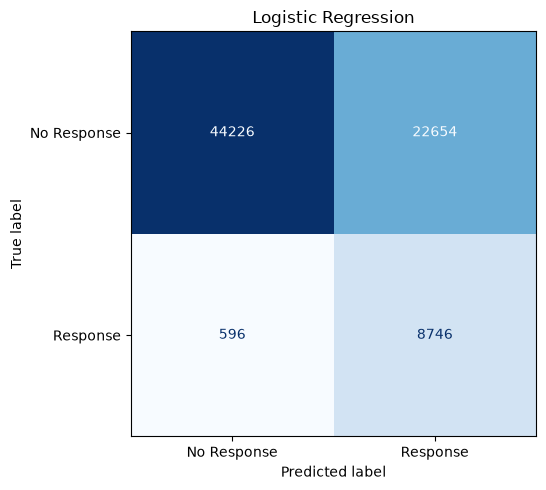

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrices for all finalized models

n_models = len(final_models)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(6 * n_models, 5)
)

# Ensure axes is iterable when only one model is included
if n_models == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(
    axes,
    model_predictions.items()
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Response", "Response"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(model_name)

plt.tight_layout()
plt.show()

### Precision–Recall Curves

Precision–Recall curves compare each model's tradeoff between precision and recall across all possible classification thresholds. Average Precision summarizes performance across the Precision–Recall curve and is particularly informative for evaluating performance on the minority response class.

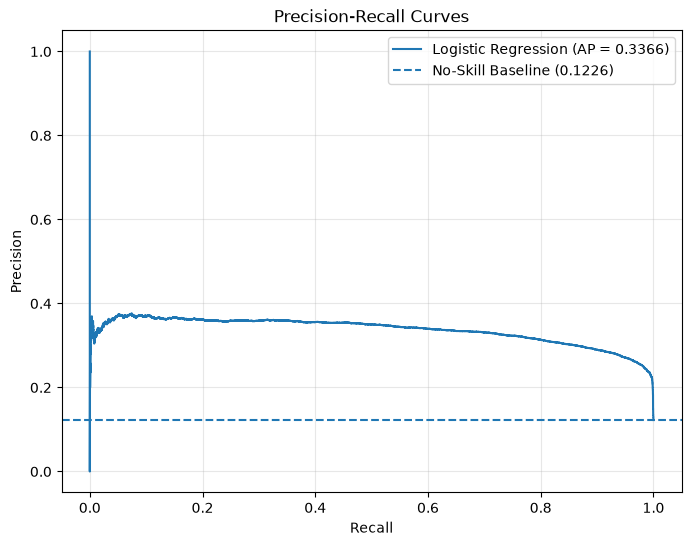

In [61]:
from sklearn.metrics import precision_recall_curve

# Plot Precision-Recall curves

plt.figure(figsize=(8, 6))

for model_name, y_prob in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    average_precision = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {average_precision:.4f})"
    )

# No-skill baseline equals the positive-class prevalence
positive_rate = y_test.mean()

plt.axhline(
    positive_rate,
    linestyle="--",
    label=f"No-Skill Baseline ({positive_rate:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ROC Curves

ROC curves compare each model's true-positive rate and false-positive rate across all possible classification thresholds. ROC AUC summarizes each model's ability to discriminate between response classes. Because the dataset is highly imbalanced, ROC curves are interpreted alongside the Precision–Recall curves, which provide a more informative assessment of minority-class performance.

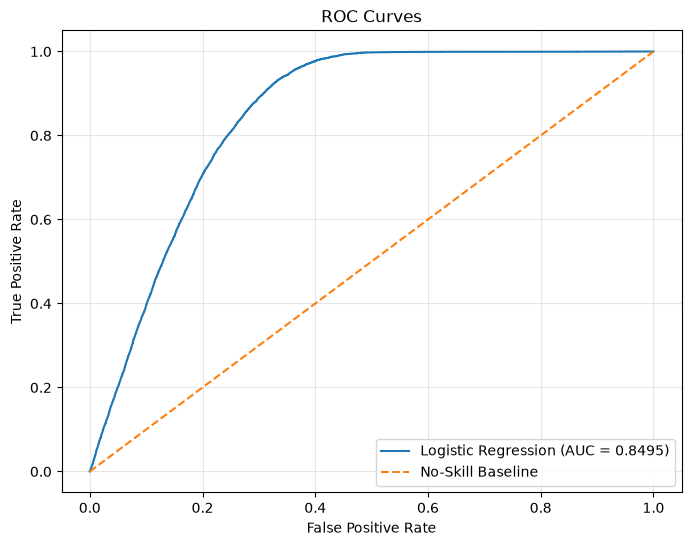

In [63]:
from sklearn.metrics import roc_curve

# Plot ROC curves

plt.figure(figsize=(8, 6))

for model_name, y_prob in model_probabilities.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-Skill Baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Classification Threshold

The evaluation metrics presented throughout this analysis use the default classification threshold of 0.50. The operating points shown on the Precision-Recall and ROC curves correspond to this threshold.

Although a threshold of 0.50 provides a consistent basis for comparing models, the optimal operating threshold ultimately depends on business objectives and the relative costs of false positives and false negatives. For example, if identifying as many potential responders as possible is the primary objective, a lower threshold may be preferred to increase recall. Conversely, if minimizing unnecessary marketing costs is more important, a higher threshold may be selected to improve precision.

## Model Interpretation

### Logistic Regression Coefficients

Logistic Regression coefficients indicate the direction and magnitude of each feature's association with the predicted log-odds of customer response, holding all other predictors constant. Positive coefficients are associated with higher predicted response, while negative coefficients are associated with lower predicted response.

Because categorical encoding produces a large number of model features, only the strongest positive and negative coefficients are displayed. Odds ratios are also reported to provide a more intuitive interpretation of each coefficient.

Interpretation depends on the feature transformation:

- Numeric coefficients represent a one-standard-deviation increase because numeric variables are standardized.
- Binary coefficients compare a value of 1 with a value of 0.
- Ordinal coefficients represent a one-level increase in the encoded order.
- One-hot encoded coefficients compare each displayed category with the omitted reference category.

In [76]:
# Extract Logistic Regression coefficients

import numpy as np

logreg_preprocessor = logreg_model.named_steps["preprocessor"]
logreg_classifier = logreg_model.named_steps["classifier"]

feature_names = logreg_preprocessor.get_feature_names_out()
coefficients = logreg_classifier.coef_[0]

logreg_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
})

# Remove ColumnTransformer prefixes for readability
logreg_coefficients["Feature"] = (
    logreg_coefficients["Feature"]
    .str.replace(r"^[^_]+__", "", regex=True)
)

# Select the strongest coefficient for each original variable
variables = [
    "Age",
    "Annual_Premium",
    "Gender",
    "Vintage",
    "Previously_Insured",
    "Vehicle_Damage",
    "Vehicle_Age",
    "Region_Code",
    "Policy_Sales_Channel"
]

summary = []

for variable in variables:

    matches = logreg_coefficients[
        logreg_coefficients["Feature"].str.startswith(variable)
    ]

    strongest = matches.loc[
        matches["Coefficient"].abs().idxmax()
    ]

    summary.append(strongest)

summary = (
    pd.DataFrame(summary)
    .sort_values(
        by="Coefficient",
        key=lambda s: s.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    summary[
        ["Feature", "Coefficient", "Odds Ratio"]
    ].round(4)
)

,Feature,Coefficient,Odds Ratio
0,Previously_Insured,-4.0271,0.0178
1,Vehicle_Damage_Yes,1.9432,6.9812
2,Policy_Sales_Channel_160.0,-1.6995,0.1828
3,Region_Code_11.0,0.9384,2.5559
4,Age,-0.4181,0.6583
5,Vehicle_Age,0.2860,1.3311
6,Gender_Male,0.0766,1.0796
7,Annual_Premium,0.0097,1.0097
8,Vintage,-0.0053,0.9947


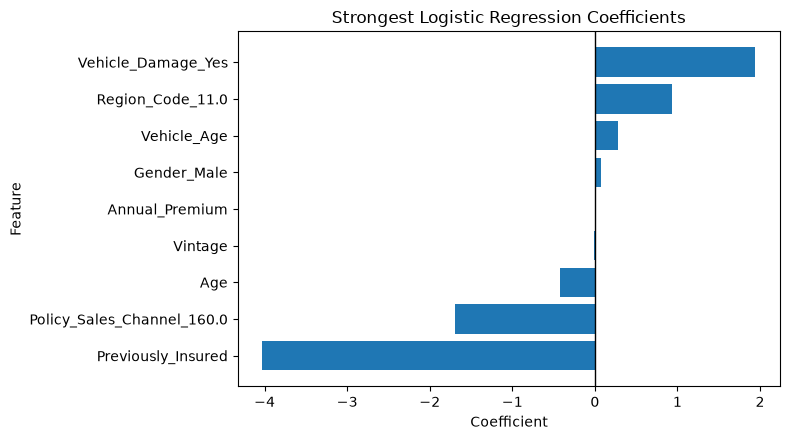

In [78]:
# Plot the strongest Logistic Regression coefficients

plot_coefficients = summary.sort_values("Coefficient")

plt.figure(figsize=(8, 4.5))

plt.barh(
    plot_coefficients["Feature"],
    plot_coefficients["Coefficient"]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Strongest Logistic Regression Coefficients")

plt.tight_layout()
plt.show()

Interpretation: Lorem ipsum dolor

### Operating Point Comparison

The previous section compared candidate models using the default classification threshold (0.50) to ensure a consistent basis for model selection. After selecting Logistic Regression as the preferred model, additional threshold analysis was performed to illustrate how the operating point can be adjusted to balance precision and recall according to business objectives.

In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
)

# Generate predicted probabilities on the test set
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]

# Evaluate a threshold
def evaluate_threshold(threshold):

    y_pred = (y_prob_logreg >= threshold).astype(int)

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "F2": fbeta_score(y_test, y_pred, beta=2)
    }

# Compare operating thresholds
threshold_summary = pd.DataFrame([
    evaluate_threshold(0.50),
    evaluate_threshold(f1_threshold),
    evaluate_threshold(f2_threshold)
])

threshold_summary.index = [
    "Default (0.50)",
    "F1-Optimal",
    "F2-Optimal"
]

threshold_summary = threshold_summary.round(3)

display(threshold_summary)

,Threshold,Accuracy,Precision,Recall,F1,F2
Default (0.50),0.500,0.695,0.279,0.936,0.429,0.636
F1-Optimal,0.679,0.777,0.323,0.753,0.452,0.595
F2-Optimal,0.519,0.703,0.283,0.924,0.433,0.636


### Random Forest Feature Importances

### Gradient Boosting Feature Importances

## Association Analysis

Association rule mining is used to identify combinations of customer characteristics that frequently occur together with a positive response. Unlike the predictive models presented previously, association rules are descriptive rather than predictive. Their purpose is to uncover interpretable patterns that may support targeted marketing strategies or generate hypotheses for future analysis.

Rules are evaluated using support, confidence, and lift. To emphasize meaningful business relationships, the analysis focuses on rules with the highest lift.

In [83]:
from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

# Select training features for association rule mining
arm_columns = [
    "Gender",
    "Previously_Insured",
    "Vehicle_Age",
    "Vehicle_Damage",
    "Age",
    "Annual_Premium",
    "Vintage"
]

arm_data = X_train[arm_columns].copy()

# Add the response variable
arm_data["Response"] = y_train

In [ ]:
# Bin continuous variables into terciles
arm_data["Age_Group"] = pd.qcut(
    arm_data["Age"],
    q=3,
    labels=["Younger", "Middle", "Older"]
)

arm_data["Premium_Group"] = pd.qcut(
    arm_data["Annual_Premium"],
    q=3,
    labels=["Low", "Medium", "High"]
)

arm_data["Vintage_Group"] = pd.qcut(
    arm_data["Vintage"],
    q=3,
    labels=["Short", "Medium", "Long"]
)

# Remove the original continuous variables
arm_data = arm_data.drop(
    columns=["Age", "Annual_Premium", "Vintage"]
)

# Convert all variables to categorical strings
arm_data = arm_data.astype(str)

# One-hot encode transactions for Apriori
arm_encoded = pd.get_dummies(
    arm_data,
    prefix_sep="="
).astype(bool)

display(arm_encoded.head())

,Gender=Female,Gender=Male,Previously_Insured=0,Previously_Insured=1,Vehicle_Age=1-2 Year,Vehicle_Age=< 1 Year,Vehicle_Age=> 2 Years,Vehicle_Damage=No,Vehicle_Damage=Yes,Response=0,Response=1,Age_Group=Middle,Age_Group=Older,Age_Group=Younger,Premium_Group=High,Premium_Group=Low,Premium_Group=Medium,Vintage_Group=Long,Vintage_Group=Medium,Vintage_Group=Short
274710,False,True,True,False,False,True,False,False,True,True,False,False,False,True,False,True,False,False,True,False
216539,True,False,False,True,False,True,False,True,False,True,False,False,False,True,True,False,False,False,False,True
78983,True,False,True,False,False,True,False,False,True,False,True,True,False,False,False,False,True,False,False,True
218368,False,True,True,False,False,True,False,False,True,True,False,True,False,False,True,False,False,True,False,False
307215,True,False,True,False,False,True,False,False,True,True,False,False,False,True,True,False,False,True,False,False


In [85]:
# Generate frequent itemsets

frequent_itemsets = apriori(
    arm_encoded,
    min_support=0.01,
    use_colnames=True,
    max_len=4,
    low_memory=True
).sort_values(
    "support",
    ascending=False
).reset_index(drop=True)

print(f"Frequent itemsets found: {len(frequent_itemsets):,}")

display(frequent_itemsets.head(10))

Frequent itemsets found: 2,452


,support,itemsets
0,0.877437,frozenset({Response=0})
1,0.541873,frozenset({Previously_Insured=0})
2,0.540463,frozenset({Gender=Male})
3,0.525424,frozenset({Vehicle_Age=1-2 Year})
4,0.504971,frozenset({Vehicle_Damage=Yes})
5,0.495029,frozenset({Vehicle_Damage=No})
6,0.492425,"frozenset({Vehicle_Damage=No, Response=0})"
7,0.479076,"frozenset({Vehicle_Damage=Yes, Previously_Insu..."
8,0.465841,"frozenset({Gender=Male, Response=0})"
9,0.459537,frozenset({Gender=Female})


In [86]:
# Generate association rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.15
)

# Retain rules predicting a positive response
response_rules = (
    rules[
        rules["consequents"].eq(
            frozenset({"Response=1"})
        )
        & (rules["lift"] > 1)
    ]
    .loc[
        :,
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction"
        ]
    ]
    .sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    )
    .reset_index(drop=True)
)

print(f"Positive-response rules found: {len(response_rules):,}")

Positive-response rules found: 195


In [87]:
# Format rules for readability

def format_itemset(itemset):
    return ", ".join(sorted(itemset))


response_rules_display = response_rules.copy()

response_rules_display["Rule"] = (
    response_rules_display["antecedents"].apply(format_itemset)
    + " → "
    + response_rules_display["consequents"].apply(format_itemset)
)

response_rules_display = response_rules_display[
    [
        "Rule",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction"
    ]
]

with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None
):
    display(response_rules_display.head(10).round(4))

,Rule,support,confidence,lift,leverage,conviction
0,"Age_Group=Middle, Premium_Group=High, Vehicle_Damage=Yes → Response=1",0.0202,0.3306,2.6972,0.0127,1.3107
1,"Age_Group=Middle, Previously_Insured=0, Vehicle_Damage=Yes → Response=1",0.0587,0.3247,2.6490,0.0365,1.2993
2,"Age_Group=Middle, Vehicle_Age=1-2 Year, Vehicle_Damage=Yes → Response=1",0.0477,0.3201,2.6120,0.0294,1.2906
3,"Age_Group=Middle, Premium_Group=Medium, Vehicle_Damage=Yes → Response=1",0.0189,0.3201,2.6116,0.0116,1.2905
4,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Long → Response=1",0.0196,0.3169,2.5856,0.0120,1.2845
5,"Age_Group=Middle, Gender=Female, Vehicle_Damage=Yes → Response=1",0.0248,0.3163,2.5806,0.0152,1.2833
6,"Age_Group=Middle, Premium_Group=High, Previously_Insured=0 → Response=1",0.0204,0.3136,2.5585,0.0124,1.2783
7,"Age_Group=Middle, Vehicle_Damage=Yes → Response=1",0.0588,0.3131,2.5545,0.0358,1.2774
8,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Short → Response=1",0.0198,0.3124,2.5490,0.0120,1.2761
9,"Age_Group=Middle, Gender=Male, Vehicle_Damage=Yes → Response=1",0.0340,0.3108,2.5358,0.0206,1.2731


Interpretation: Lorem ipsum dolor

# Conclusion

Lorem ipsum dolor